In [1]:
import snappy
import numpy as np
import matplotlib.pyplot as plt
from invariants import *

### TODO
- write a function to draw wedge regions for different invariants in the $e$-$b_1$ plane
- when $\sigma$ and $\upsilon$ are different, draw wedge regions for $T(4,q)$ in the $e$-$b_1$ plane
- For $T(4,5)$ try to find 2 band moves to the unknot ($\gamma_4(T(4,5)) = 2$ so we need exactly two bands) and compute their normal euler number and upsilon to place them in the wedge plot

# Plot Knot Geography $T(p,q)$
Gordon-Litherland signature bound:
$$
W_\sigma = \left\{
2b \ge \left| e - 2\sigma(K) \right|
\right\}
$$

In [2]:
def plot_sig_bound(K, erange=(-30,30), brange=(0,30), resolution=300, fig=None, ax=None, plot_points=False):
    if fig is None and ax is None:
        fig, ax = plt.subplots()
    
    sigma = K.signature()

    # integer points
    if plot_points:
        int_points = [(e,b) 
                      for e in range(erange[0], erange[1]+1) 
                      for b in range(brange[0], brange[1]+1)]
        realizable_points = [(e,b) for e,b in int_points if 2*b >= abs(e - 2 * sigma)]
        realizable_e = [e for e,_ in realizable_points]
        realizable_b = [b for _,b in realizable_points]

        ax.scatter(realizable_e, realizable_b, s=0.5, c='red')
    
    # signature bound
    es = np.linspace(erange[0], erange[1], resolution)
    bs = np.linspace(brange[0], brange[1], resolution)
    e,b = np.meshgrid(es, bs)

    ax.imshow(2 * b >= abs(e - 2 * sigma),
              extent=(erange[0],erange[1],brange[0],brange[1]), origin='lower',
              cmap='Greys', alpha=0.3)
    
    bound_line = 0.5 * abs(es - 2 * sigma)
    ax.plot(es, bound_line, label="$2b_1\\geq |e-2\\sigma|$")

    plt.title(f"Signature bound, $\\sigma={sigma}$")
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
    plt.xlim(erange[0], erange[1])
    plt.ylim(brange[0], brange[1])
    plt.xlabel(r'$e$')
    plt.ylabel(r'$b$')
    #plt.show()

    return fig, ax

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Signature bound, $\\sigma=-8$'}, xlabel='$e$', ylabel='$b$'>)

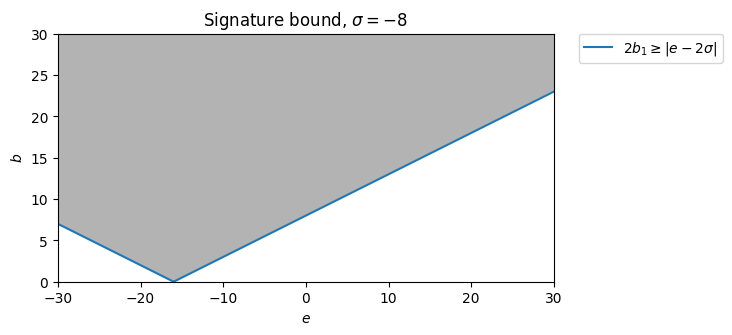

In [3]:
T45 = snappy.Link('T(4,5)')
plot_sig_bound(T45)

### $\Upsilon(1)$ bound
Per [Allen](https://arxiv.org/pdf/2007.14332):
$$
    b_1 \ge \left| 2\Upsilon(1) - \frac{e}{2} \right|
$$

In [4]:
def plot_upsilon_bound(K, erange=[-30,30], brange=[0,30], resolution=300, fig=None, ax=None, plot_points=False):
    if fig is None and ax is None:
        fig, ax = plt.subplots()
    
    ups = upsilon(K)
    
    # integer points
    if plot_points:
        int_points = [(e,b) 
                      for e in range(erange[0], erange[1]+1) 
                      for b in range(brange[0], brange[1]+1)]
        realizable_points = [(e,b) for e,b in int_points if b >= abs(2 * ups - 0.5 * e)]
        realizable_e = [e for e,_ in realizable_points]
        realizable_b = [b for _,b in realizable_points]
        ax.scatter(realizable_e, realizable_b, s=0.5, c='red')

    # upsilon bound
    es = np.linspace(erange[0], erange[1], resolution)
    bs = np.linspace(brange[0], brange[1], resolution)
    e,b = np.meshgrid(es, bs)

    ax.imshow(b >= abs(2 * ups - 0.5 * e),
              extent=(erange[0],erange[1],brange[0],brange[1]), origin='lower',
              cmap='Greys', alpha=0.3)

    bound_line = abs(2 * ups - 0.5 * es)
    ax.plot(es, bound_line, label="$b_1\\geq \\left|2*\\Upsilon(1)-\\frac{e}{2}\\right|$")

    plt.title(f"$\\Upsilon(1)$ bound, $\\Upsilon={ups}$")
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
    plt.xlim(erange[0], erange[1])
    plt.ylim(brange[0], brange[1])
    plt.xlabel(r'$e$')
    plt.ylabel(r'$b$')
    #plt.show()
    
    return fig, ax

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': '$\\Upsilon(1)$ bound, $\\Upsilon=-4$'}, xlabel='$e$', ylabel='$b$'>)

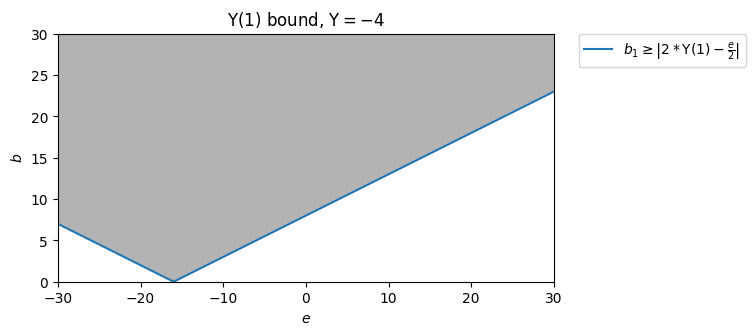

In [5]:
plot_upsilon_bound(T45)

## Put them together!

In [12]:
def plot_bounds(K, erange=(-30,30), brange=(0,30), resolution=300):
    fig, ax = plt.subplots()
    fig, ax = plot_sig_bound(K, erange=erange, brange=brange, resolution=resolution)
    fig, ax = plot_upsilon_bound(K, erange=erange, brange=brange, resolution=resolution)

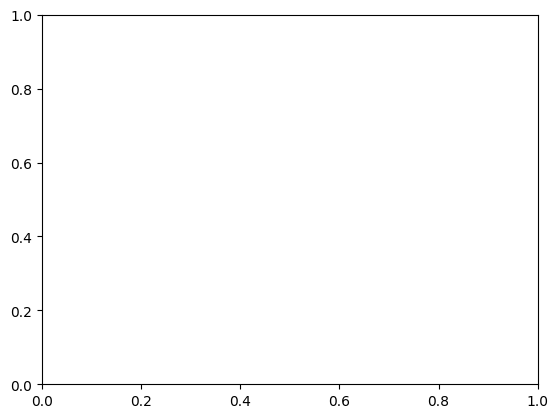

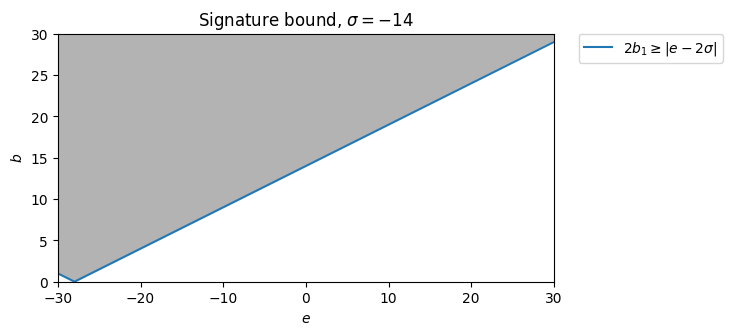

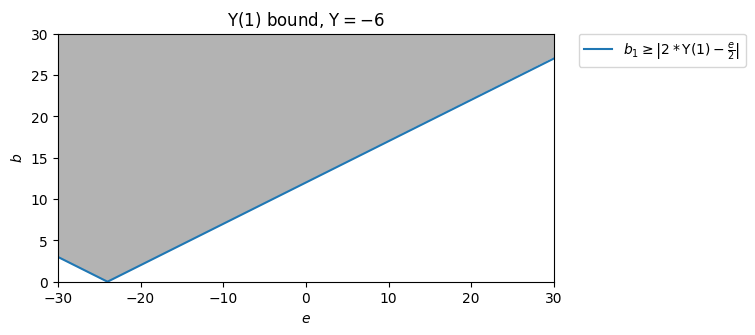

In [16]:
T47 = snappy.Link('T(4,7)')
plot_bounds(T47)